In [1]:
import matplotlib as plt
import pandas as pd

In [5]:
df_matchups = pd.read_csv('../../matchups_v1.1.csv')
df_matchups['date'] = pd.to_datetime(df_matchups['gid'].str[3:11], format="%Y%m%d")

# Model 1.1 Analysis

## Yearly Averages

### Batters

Plotting the average ELO rating of all batters over each year shows some interesting things:
- You can clearly see where the DH rules were implemented, first in the AL, then universally. Since pitchers are removed from the pool of hitters each time, the average jumps (same in 2020).
- The end of the Deadball Era and the 1969 lowering of the mound didn't really impact batter ELO.

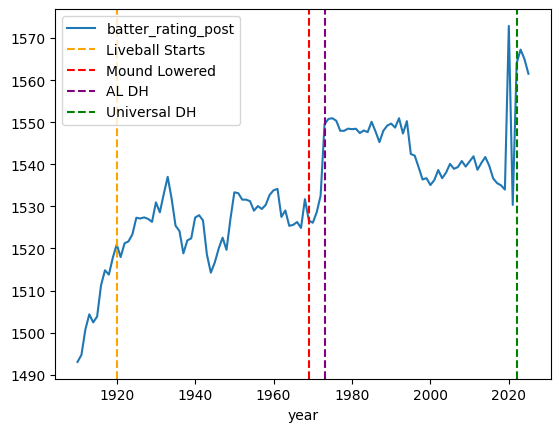

In [6]:
ax = df_matchups[['date', 'batter', 'batter_rating_post']] \
    .sort_values('date') \
    .assign(year=lambda x: x['date'].dt.year) \
    .groupby(['batter', 'year'])['batter_rating_post'] \
    .last().reset_index() \
    .groupby('year')['batter_rating_post'].mean().plot()

ax.axvline(x=1920, color='orange', linestyle='--', linewidth=1.5, label='Liveball Starts')
ax.axvline(x=1969, color='red', linestyle='--', linewidth=1.5, label='Mound Lowered')
ax.axvline(x=1973, color='purple', linestyle='--', linewidth=1.5, label='AL DH')
ax.axvline(x=2022, color='green', linestyle='--', linewidth=1.5, label='Universal DH')
ax.legend()

## Distributions

### Year-End Distribution

#### Batters

array([[<Axes: title={'center': 'final_rating'}>]], dtype=object)

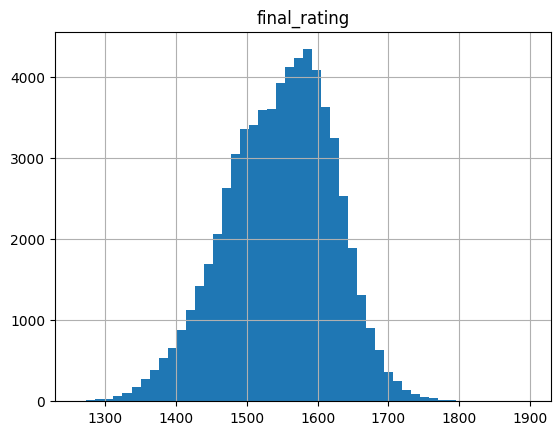

In [7]:
df_matchups[['date', 'batter', 'batter_rating_post']] \
    .sort_values('date') \
    .assign(year=lambda x: x['date'].dt.year) \
    .groupby(['batter', 'year'])['batter_rating_post'] \
    .agg(final_rating='last', instances='count') \
    .reset_index() \
    .query('instances >= 10')[['final_rating']].hist(bins=50)

#### Pitchers

<Axes: xlabel='year'>

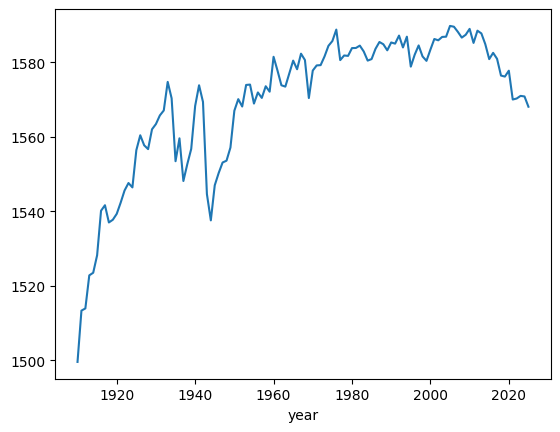

In [8]:
df_matchups[['date', 'pitcher', 'pitcher_rating_post']] \
    .sort_values('date') \
    .assign(year=lambda x: x['date'].dt.year) \
    .groupby(['pitcher', 'year'])['pitcher_rating_post'] \
    .last().reset_index() \
    .groupby('year')['pitcher_rating_post'].mean().plot()
